# **Egyptian license plate detection system 🛣️**

## 1️⃣ Required Libraries

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2026-05-13 08:14:21.663402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778660061.892076     107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778660061.956320     107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778660062.486481     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778660062.486532     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778660062.486535     107 computation_placer.cc:177] computation placer alr

## 2️⃣ Read Dataset

In [2]:
IMG_SIZE = 416
GRID_SIZE = 26          # 416 / 16 = 26 (4 MaxPooling layers)
CELL_SIZE = IMG_SIZE / GRID_SIZE
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

IMG_FOLDER = '/kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset/Vehicles'
LABEL_FOLDER = '/kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset/Vehicles Labeling'

## 3️⃣ Processing

In [3]:
def get_pairs(img_folder, label_folder):
    imgs, labels = [], []
    for f in sorted(os.listdir(img_folder)):
        if f.endswith('.jpg'):
            img_p = os.path.join(img_folder, f)
            label_p = os.path.join(label_folder, f.replace('.jpg', '.txt'))
            if os.path.exists(label_p):
                imgs.append(img_p)
                labels.append(label_p)
    return imgs, labels

img_paths, label_paths = get_pairs(IMG_FOLDER, LABEL_FOLDER)
print(f"Total pairs: {len(img_paths)}")

X_train, X_temp, y_train, y_temp = train_test_split(img_paths, label_paths, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Total pairs: 2031
Train: 1624 | Val: 203 | Test: 204


In [4]:
def parse_label(path_tensor):
    path = path_tensor.numpy().decode()
    label = np.zeros((GRID_SIZE, GRID_SIZE, 5), dtype=np.float32)

    with open(path, 'r') as f:
        parts = f.readline().strip().split()

    if len(parts) >= 5:
        x_global, y_global, w, h = map(float, parts[1:5])

        i = int(y_global * GRID_SIZE)  # row
        j = int(x_global * GRID_SIZE)  # col

        i = min(i, GRID_SIZE - 1)
        j = min(j, GRID_SIZE - 1)

        x_offset = (x_global * GRID_SIZE) - j
        y_offset = (y_global * GRID_SIZE) - i

        label[i, j, 0] = 1.0        # confidence
        label[i, j, 1] = x_offset   
        label[i, j, 2] = y_offset   
        label[i, j, 3] = w          
        label[i, j, 4] = h          

    return label

In [5]:
def load_image(img_path, label_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    label = tf.py_function(parse_label, [label_path], tf.float32)
    label.set_shape((GRID_SIZE, GRID_SIZE, 5))
    return img, label


def make_dataset(x, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(512)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)


I0000 00:00:1778660094.071555     107 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 4️⃣ Modeling

In [6]:
def conv_bn_relu(x, filters, kernel=3, strides=1):
    x = layers.Conv2D(filters, kernel, strides=strides, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [7]:
def residual_block(x, filters):
    shortcut = x
    x = conv_bn_relu(x, filters)
    x = conv_bn_relu(x, filters)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [8]:
def build_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = conv_bn_relu(inputs, 32)
    x = layers.MaxPooling2D()(x)           # 208

    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D()(x)           # 104

    x = residual_block(x, 128)
    x = layers.MaxPooling2D()(x)           # 52

    x = residual_block(x, 256)
    x = layers.MaxPooling2D()(x)           # 26

    x = conv_bn_relu(x, 512)
    x = layers.Dropout(0.3)(x)
    x = conv_bn_relu(x, 256)

    # Output: [confidence, x_offset, y_offset, w, h]
    outputs = layers.Conv2D(5, 1, activation='sigmoid', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 416, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 416, 416,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 416, 416,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 416, 416,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 208, 208,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 208, 208,  │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 208, 208,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 208, 208,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 104, 104,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 104, 104,  │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 104, 104,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 104, 104,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 104, 104,  │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 104, 104,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 104, 104,  │      8,192 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 104, 104,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 104, 104,  │        512 │ conv2d_4[0][0]  

 Total params: 3,534,821 (13.48 MB)

 Trainable params: 3,530,789 (13.47 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [9]:
def detection_loss(y_true, y_pred):
    obj_mask    = y_true[..., 0]      # (batch, 26, 26)
    no_obj_mask = 1.0 - obj_mask      # (batch, 26, 26)

    conf_true = y_true[..., 0]        # (batch, 26, 26)
    conf_pred = y_pred[..., 0]        # (batch, 26, 26)

    bce = tf.keras.losses.binary_crossentropy(
        conf_true[..., tf.newaxis],   # (batch, 26, 26, 1)
        conf_pred[..., tf.newaxis],   # (batch, 26, 26, 1)
        axis=-1
    )  # -> (batch, 26, 26)

    obj_conf_loss   = obj_mask    * bce
    noobj_conf_loss = no_obj_mask * bce

    obj_mask_exp = obj_mask[..., tf.newaxis]   

    xy_loss = obj_mask_exp * tf.square(y_true[..., 1:3] - y_pred[..., 1:3])
    wh_loss = obj_mask_exp * tf.square(
        tf.sqrt(tf.maximum(y_true[..., 3:5], 1e-7)) -
        tf.sqrt(tf.maximum(y_pred[..., 3:5], 1e-7))
    )

    n_obj = tf.reduce_sum(obj_mask) + 1e-6

    total_loss = (
        5.0  * tf.reduce_sum(obj_conf_loss)   / n_obj +
        0.5  * tf.reduce_mean(noobj_conf_loss)        +
        10.0 * tf.reduce_sum(xy_loss)          / n_obj +
        5.0  * tf.reduce_sum(wh_loss)          / n_obj
    )

    return total_loss

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=detection_loss,
    metrics=['mae']
)

callbacks = [
    # tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_plate_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1778660102.166028     167 service.cc:152] XLA service 0x7c389c003960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778660102.166093     167 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778660103.524368     167 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/102 ━━━━━━━━━━━━━━━━━━━━ 37:53 23s/step - loss: 9.6494 - mae: 0.4885

I0000 00:00:1778660118.374584     167 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 3.0686 - mae: 0.4565

...


Epoch 48: val_loss did not improve from 0.37548
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - loss: 0.0198 - mae: 0.2786 - val_loss: 0.4588 - val_mae: 0.2796 - learning_rate: 1.0000e-06
Epoch 49/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0192 - mae: 0.2786

Premature end of JPEG file



Epoch 49: val_loss did not improve from 0.37548
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - loss: 0.0192 - mae: 0.2786 - val_loss: 0.4564 - val_mae: 0.2796 - learning_rate: 1.0000e-06
Epoch 50/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0197 - mae: 0.2785

Premature end of JPEG file



Epoch 50: val_loss did not improve from 0.37548
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - loss: 0.0197 - mae: 0.2785 - val_loss: 0.4572 - val_mae: 0.2797 - learning_rate: 1.0000e-06


## 5️⃣ Evaluation

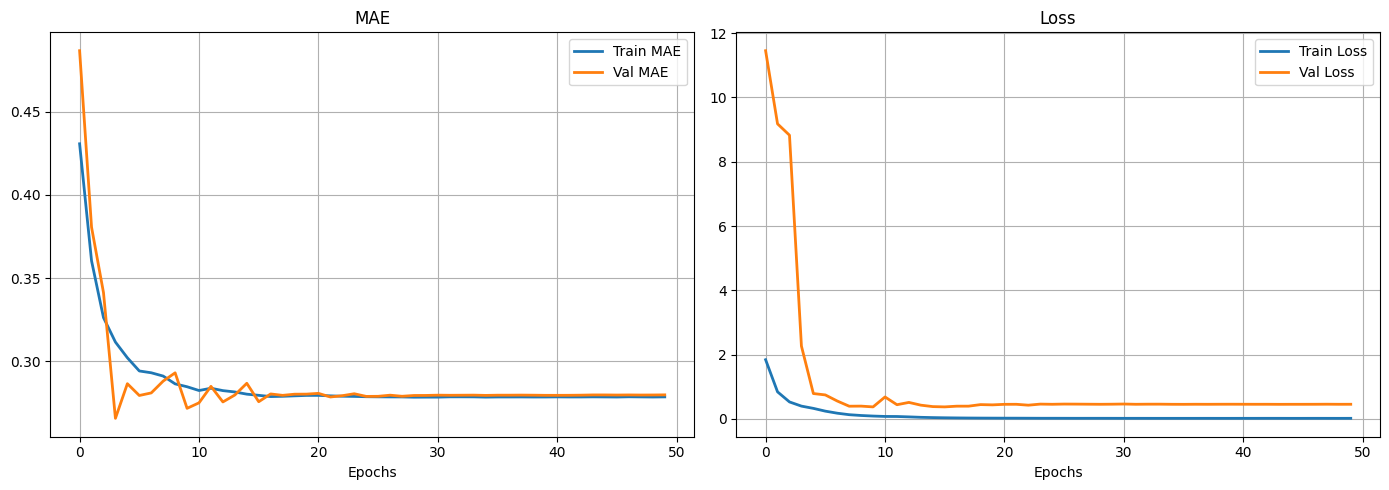

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'],     label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE',   linewidth=2)
plt.title('MAE')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 6️⃣ Testing

In [12]:
def predict_plate(img_path, confidence_threshold=0.3):
    # Load and preprocess
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_resized = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_batch = np.expand_dims(img_resized, axis=0)

    # Predict
    pred = model.predict(img_batch, verbose=0)[0]  # (26, 26, 5)

    conf_map = pred[..., 0]
    idx = np.unravel_index(np.argmax(conf_map), conf_map.shape)
    i, j = idx

    conf     = pred[i, j, 0]
    x_offset = pred[i, j, 1]
    y_offset = pred[i, j, 2]
    w        = pred[i, j, 3]
    h        = pred[i, j, 4]

    x_global = (j + x_offset) / GRID_SIZE
    y_global = (i + y_offset) / GRID_SIZE

    print(f"Best cell: ({i}, {j}) | Confidence: {conf:.3f}")
    print(f"Global box: x={x_global:.3f}, y={y_global:.3f}, w={w:.3f}, h={h:.3f}")

    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = original.shape

    if conf > confidence_threshold:
        x1 = int((x_global - w / 2) * w_img)
        y1 = int((y_global - h / 2) * h_img)
        x2 = int((x_global + w / 2) * w_img)
        y2 = int((y_global + h / 2) * h_img)

        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_img, x2), min(h_img, y2)

        cv2.rectangle(original, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(original, f"Plate {conf:.2f}", (x1, max(y1-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        print(f"Detected: ({x1},{y1}) -> ({x2},{y2})")
    else:
        print(f"No confident detection (conf={conf:.3f} < threshold={confidence_threshold})")

    plt.figure(figsize=(10, 8))
    plt.imshow(original)
    plt.axis('off')
    plt.title(f"Confidence: {conf:.3f}")
    plt.show()

    return pred

Best cell: (12, 12) | Confidence: 1.000
Global box: x=0.495, y=0.488, w=0.217, h=0.069
Detected: (278,435) -> (434,501)


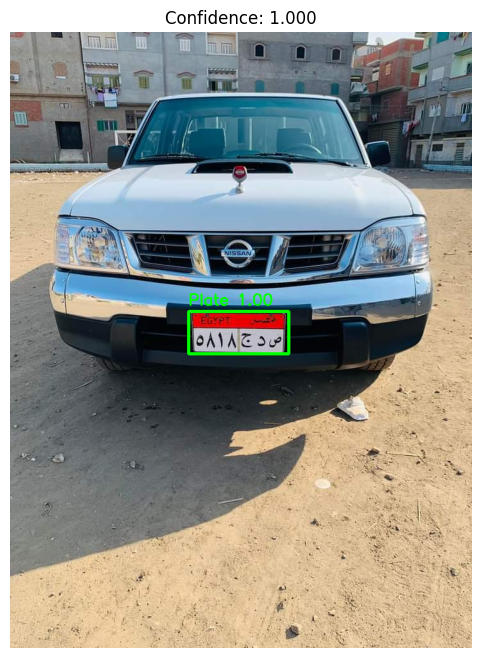

In [13]:
if X_test:
    predict_plate('/kaggle/input/datasets/abdulrahmanelbanna/cars-cv/Data/FB_IMG_1698878692237.jpg')

Best cell: (16, 14) | Confidence: 1.000
Global box: x=0.562, y=0.641, w=0.167, h=0.069
Detected: (344,581) -> (465,647)


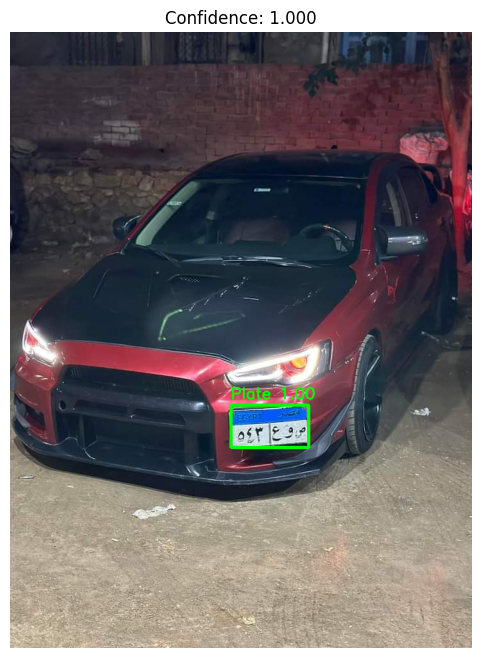

In [14]:
if X_test:
    predict_plate('/kaggle/input/datasets/abdulrahmanelbanna/cars-cv/Data/FB_IMG_1698950337689.jpg')

## **ThankYou**🎀🫶🏻💓